In [212]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline


In [213]:
df = pd.read_csv('Book1.csv')
df.head(4)

,Weight,Height
0,30,120
1,60,143
2,50,130
3,37,120


Text(0, 0.5, 'Height')

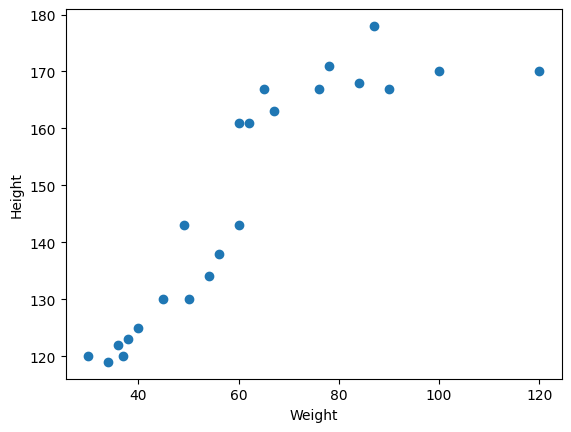

In [214]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [215]:
df.corr()

,Weight,Height
Weight,1.000000,0.882307
Height,0.882307,1.000000


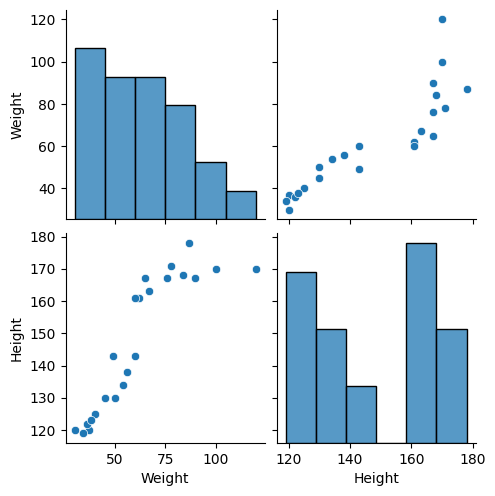

In [216]:
sns.pairplot(df)

In [217]:
X=df[['Weight']] # Independent feature - Dataframe
y=df['Height']   # Dependent feature should be in series 
np.array(X).shape # Keep this format 

(23, 1)

In [218]:
X_series=df['Weight']
np.array(X_series).shape

(23,)

In [219]:
# Train and test split 
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = .25,random_state = 42)


In [220]:
X_train.shape

(17, 1)

# Standardization

In [221]:
from sklearn.preprocessing import StandardScaler

In [222]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)


In [223]:
X_test = scaler.transform(X_test)
X_test

array([[-1.15164977],
       [ 2.42899584],
       [-1.61366856],
       [ 0.52316833],
       [ 1.15844417],
       [ 3.58404281]])

Linear Regression

In [224]:
from sklearn.linear_model import LinearRegression


In [225]:
regression = LinearRegression()

In [226]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [227]:
print("My Slope is :" ,regression.coef_)
print("My Intercept is :" ,regression.intercept_)

My Slope is : [18.03052302]
My Intercept is : 145.47058823529412


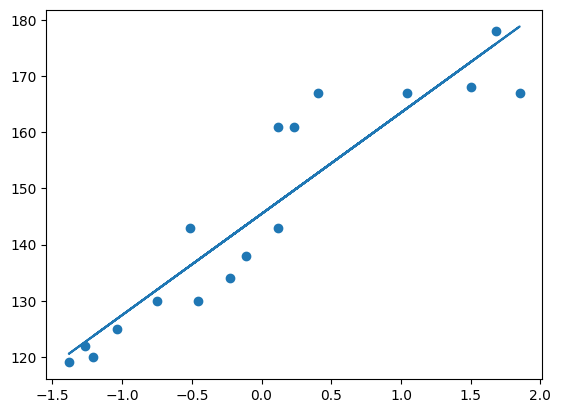

In [228]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

# Prediction of test data 

1. predicted height output = intercept + coef(Weight)

2. y_pred = 145.47 + 18.03(X_test)

In [229]:
y_pred = regression.predict(X_test)

Performance Metrics

In [230]:
from sklearn.metrics import mean_absolute_error , mean_squared_error

In [231]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

346.9635856929445
12.904719862739656
18.626958573340534


# R Square (R²)

**Formula:**

$$R^2 = 1 - \frac{SSR}{SST}$$

Where:
- **R²** = Coefficient of Determination
- **SSR** = Sum of Squares of Residuals = $\sum(y_i - \hat{y}_i)^2$

- **SST** = Total Sum of Squares = $\sum(y_i - \bar{y})^2$

In [232]:
from sklearn.metrics import r2_score

In [233]:
score = r2_score(y_test,y_pred)
print(score)


0.30394599693808844


# Adjusted R² 

**Formula:**

$$R^2_{adj} = 1 - \frac{(1-R^2)(n-1)}{(n-k-1)}$$

Where:
- **R²** = R² score of the model

- **n** = Number of observations

- **k** = Number of predictor variables

In [234]:
#display adjusted R-squared
adj_r2 = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(adj_r2)

0.1299324961726105


OLS (Ordinary Least Squares) Linear Regression is a method used to find the best-fit straight line by minimizing the sum of squared errors between actual and predicted values.

In [ ]:
%pip install statsmodels
import statsmodels.api as sm

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
model = sm.OLS(y_train,X_train).fit()

In [ ]:
prediction = model.predict(X_test)
print(prediction)